## Document Forgery Detection: Machine Learning Classification Report

### Overview

This notebook loads the feature matrix generated by the \forged_document_detector.py` script, trains an ensemble model (Random Forest Classifier), and evaluates its performance on both genuine and forged documents. The goal is to evaluate the efficiency of the tampered document detector.`


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import joblib 
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [ ]:
# Load the Training Dataset
df_train_raw = pd.read_csv("ml_training_data.csv")

print("Dataset shape:", df_train_raw.shape)
df_train_raw.head()

print("Label distribution:")
print(df_train_raw["Label"].value_counts())

assert df_train_raw["Label"].nunique() == 2, (
    "ERROR: Dataset contains only one class. "
    "Forgery detection cannot be trained."
)


Dataset shape: (76, 24)
Label distribution:
Label
1    39
0    37
Name: count, dtype: int64


In [31]:
# Feature / Target Split
X = df_train_raw.drop(columns=["Document_ID", "Label"])
y = df_train_raw["Label"]

print("Feature count:", X.shape[1])


Feature count: 22


### Train/Test Split (70:30 Ratio)

In [ ]:
# Test size of 30% of the Training CSV
X_train, X_test, Y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 53
Testing samples: 23


### Baseline Model

In [33]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, Y_train)

dummy_preds = dummy.predict(X_test)

print("=== BASELINE (Most Frequent Class) ===")
print("Accuracy:", accuracy_score(y_test, dummy_preds))
print(classification_report(y_test, dummy_preds))


=== BASELINE (Most Frequent Class) ===
Accuracy: 0.5217391304347826
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.52      1.00      0.69        12

    accuracy                           0.52        23
   macro avg       0.26      0.50      0.34        23
weighted avg       0.27      0.52      0.36        23



### Random Forest Classifier Training

In [35]:
# 1. Train the Model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, Y_train)



RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_split=5, n_estimators=300, random_state=42)

In [36]:
y_pred = rf_model.predict(X_test)

print("=== RANDOM FOREST RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


=== RANDOM FOREST RESULTS ===
Accuracy: 0.6521739130434783
              precision    recall  f1-score   support

           0       0.64      0.64      0.64        11
           1       0.67      0.67      0.67        12

    accuracy                           0.65        23
   macro avg       0.65      0.65      0.65        23
weighted avg       0.65      0.65      0.65        23



#### Save the Trained Model

This avoids having to retrain the model every time you want to make a prediction.

In [ ]:
MODEL_DIR = "trained_models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "forged_document_rf_model.pkl")

joblib.dump(rf_model, model_path)

print(f"✅ Trained model saved to: {model_path}")

### Key Results and Feature Analysis

### Confusion Matrix

The Confusion Matrix visually represents the model's performance on the testing set, detailing true positives, true negatives, and classification errors.

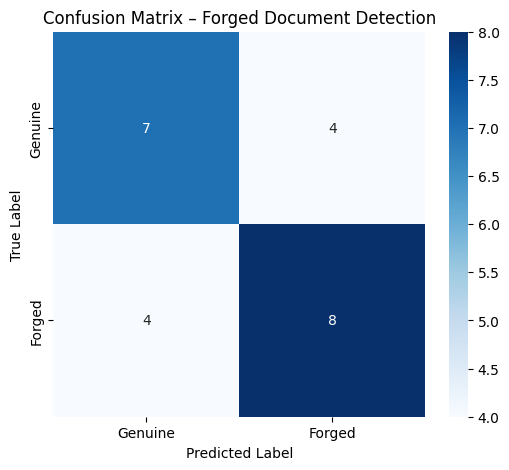

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Forged"],
    yticklabels=["Genuine", "Forged"]
)
plt.title("Confusion Matrix – Forged Document Detection")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:

# Assuming 'Y_test' are your true labels and 'Y_pred' are the Random Forest predictions
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Calculate Metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
recall = tp / (tp + fn)  # Sensitivity
precision = tp / (tp + fp)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Experimental Results for MIDV-2020 (Albanian Subset):")
print(f"{'-'*45}")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"F1-Score:  {f1_score*100:.2f}%")
print(f"{'-'*45}")
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

Experimental Results for MIDV-2020 (Albanian Subset):
---------------------------------------------
Accuracy:  65.22%
Recall:    66.67%
Precision: 66.67%
F1-Score:  66.67%
---------------------------------------------
TP: 8, TN: 7, FP: 4, FN: 4


#### Feature Importance

This chart shows which features extracted by the computer vision pipeline were most valuable to the Random Forest model's decision-making process. High importance scores indicate the most reliable indicators of forgery.

In [38]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(15)


W_Mean                     0.131124
BG_STD                     0.113695
AR_Mean                    0.087734
H_STD                      0.083445
H_Mean                     0.069586
W_STD                      0.067684
BG_Mean                    0.055514
Grad_STD                   0.053261
Char_Count                 0.052969
Ink_STD                    0.051534
AR_STD                     0.049350
Clustered_Regions_Count    0.048675
Ink_Density_Mean           0.044859
Grad_Mean                  0.044602
Ink_Mean                   0.040440
dtype: float64

In [40]:
results = X_test.copy()
results["True_Label"] = y_test.values
results["Predicted_Label"] = y_pred

errors = results[results["True_Label"] != results["Predicted_Label"]]
print("Misclassified samples:", len(errors))

errors.head()


Misclassified samples: 8


,Char_Count,NER_Detected_Count,NER_Completeness_Ratio,H_Mean,H_STD,W_Mean,W_STD,AR_Mean,AR_STD,Ink_Mean,...,Geo_Anomaly_Ratio,Ink_Anomaly_Ratio,Density_Anomaly_Ratio,BG_Mean,BG_STD,OCR_Box_Anomalies_Count,BG_Anomaly_Line_Count,Clustered_Regions_Count,True_Label,Predicted_Label
65,1052,0,0.0,14.715779,17.111634,10.259506,14.893799,0.708696,0.432708,198.358567,...,0.0,0.0,0.0,200.784874,21.946227,2,0,139,1,0
39,916,0,0.0,16.002183,18.800144,11.187773,17.416542,0.707838,0.437636,199.889804,...,0.0,0.0,0.0,201.451221,21.924354,1,0,117,0,1
71,1098,0,0.0,13.826958,15.197100,9.540073,14.015758,0.707298,0.431561,201.644745,...,0.0,0.0,0.0,200.681965,23.496673,1,0,159,1,0
34,1121,0,0.0,13.651204,14.647771,10.024978,15.288988,0.747460,0.458641,200.102461,...,0.0,0.0,0.0,201.360654,21.778805,2,0,186,0,1
14,1001,0,0.0,14.439560,15.573184,10.321678,15.902249,0.711199,0.435020,200.387232,...,0.0,0.0,0.0,201.173415,21.459468,2,0,134,1,0


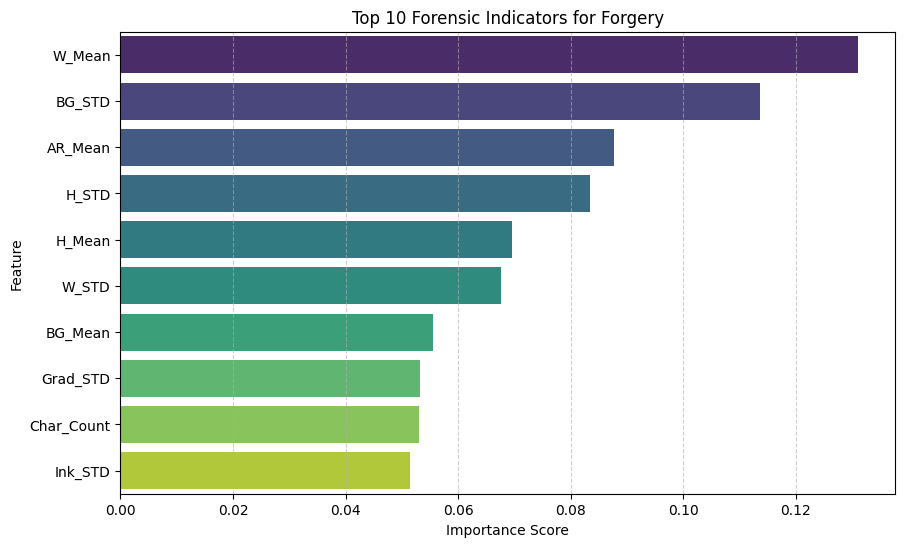

In [44]:
# --- TOP 10 FORENSIC INDICATORS ---
top_features = importances.nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title('Top 10 Forensic Indicators for Forgery')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()